In [1]:
import os

os.environ["TestingMode"] = "True"
bool(os.environ.get("TestingMode", None))

True

In [2]:
import json
import logging
import sys

import click
import pandas as pd
from datacube import Datacube
from deafrica_tools.waterbodies import get_waterbody
from odc.geo.geobox import GeoBox
from odc.geo.geom import Geometry
from odc.geo.xr import rasterize
from waterbodies.db import get_waterbodies_engine

from water_quality.grid import get_waterbodies_grid
from water_quality.io import check_directory_exists, get_filesystem, join_url
from water_quality.logs import setup_logging
from water_quality.summaries.summary import (
    add_water_quality_observations_to_db,
)
from water_quality.tasks import split_tasks

In [3]:
tasks = "test-summaries/waterbodies_for_vector_processing"
max_parallel_steps = 1
worker_idx = 0
overwrite = False
log="INFO"

In [4]:
log_level = getattr(logging, log.upper())
_log = setup_logging(log_level)

In [5]:
fs = get_filesystem(tasks, anon=False)
with fs.open(tasks, "r") as file:
    all_waterbody_uids = sorted(json.load(file))

tasks_to_run = split_tasks(
    all_waterbody_uids, max_parallel_steps, worker_idx
)

if not tasks_to_run:
    _log.warning(f"Worker {worker_idx} has no tasks to process. Exiting.")
    sys.exit(0)

_log.info(f"Worker {worker_idx} processing {len(tasks_to_run)} tasks")

2026-03-13 21:45:16,273 __main__ [INFO]: Worker 0 processing 6105 tasks


In [7]:
tasks_to_run[:2]

('e9pyrcs51q', 'e9pytuqfne')

In [8]:
grid = get_waterbodies_grid()
dc = Datacube(app="process_vector_tasks")
measurements = [
    "fai",
    "ndvi",
    "hue",
    "owt",
    "chla",
    "tsi",
    "tsm",
    "st_max",
    "st_median",
    "st_min",
    "water_mask",
]
product = "wq_annual"
dask_chunks = {"x": 800, "y": 800}
# m2_per_km2 = 1_000_000
quantiles = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

engine = get_waterbodies_engine()

2026-03-13 21:45:58,367 alembic.runtime.plugins [INFO]: setup plugin alembic.autogenerate.schemas
2026-03-13 21:45:58,367 alembic.runtime.plugins [INFO]: setup plugin alembic.autogenerate.tables
2026-03-13 21:45:58,367 alembic.runtime.plugins [INFO]: setup plugin alembic.autogenerate.types
2026-03-13 21:45:58,368 alembic.runtime.plugins [INFO]: setup plugin alembic.autogenerate.constraints
2026-03-13 21:45:58,368 alembic.runtime.plugins [INFO]: setup plugin alembic.autogenerate.defaults
2026-03-13 21:45:58,368 alembic.runtime.plugins [INFO]: setup plugin alembic.autogenerate.comments


In [9]:
failed_tasks = []
# Process each task
for idx, waterbody_uid in enumerate(tasks_to_run):
    _log.info(
        f"Processing waterbody {idx + 1} of {len(tasks_to_run)}: {waterbody_uid} "
    )
    break

2026-03-13 21:46:12,272 __main__ [INFO]: Processing waterbody 1 of 6105: e9pyrcs51q 


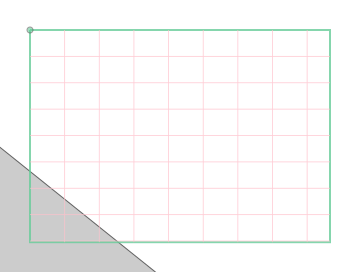

In [10]:
waterbody = get_waterbody(waterbody_uid)
waterbody_geom = Geometry(
    waterbody["geometry"].iloc[0], waterbody.crs
)
waterbody_geobox = GeoBox.from_geopolygon(
    waterbody_geom, resolution=grid.resolution, crs=grid.crs
)
waterbody_geobox

In [11]:
ds = dc.load(
                product=product,
                like=waterbody_geobox,
                measurements=measurements,
                dask_chunks=dask_chunks,
            )
ds

<xarray.Dataset> Size: 3GB
Dimensions:      (time: 25, y: 1609, x: 1732)
Coordinates:
  * time         (time) datetime64[ns] 200B 2000-07-01T23:59:59.999999 ... 20...
  * y            (y) float64 13kB 8.655e+05 8.655e+05 ... 8.494e+05 8.494e+05
  * x            (x) float64 14kB -1.095e+06 -1.095e+06 ... -1.078e+06
    spatial_ref  int32 4B 6933
Data variables:
    fai          (time, y, x) float32 279MB dask.array<chunksize=(1, 800, 800), meta=np.ndarray>
    ndvi         (time, y, x) float32 279MB dask.array<chunksize=(1, 800, 800), meta=np.ndarray>
    hue          (time, y, x) float32 279MB dask.array<chunksize=(1, 800, 800), meta=np.ndarray>
    owt          (time, y, x) float32 279MB dask.array<chunksize=(1, 800, 800), meta=np.ndarray>
    chla         (time, y, x) float32 279MB dask.array<chunksize=(1, 800, 800), meta=np.ndarray>
    tsi          (time, y, x) float32 279MB dask.array<chunksize=(1, 800, 800), meta=np.ndarray>
    tsm          (time, y, x) float32 279MB dask.array<chunksize=(1, 800, 800), meta=np.ndarray>
    st_max       (time, y, x) float32 279MB dask.array<chunksize=(1, 800, 800), meta=np.ndarray>
    st_median    (time, y, x) float32 279MB dask.array<chunksize=(1, 800, 800), meta=np.ndarray>
    st_min       (time, y, x) float32 279MB dask.array<chunksize=(1, 800, 800), meta=np.ndarray>
    water_mask   (time, y, x) float32 279MB dask.array<chunksize=(1, 800, 800), meta=np.ndarray>
Attributes:
    crs:           EPSG:6933
    grid_mapping:  spatial_ref

In [12]:
extent_da = rasterize(waterbody_geom, how=waterbody_geobox)
ds = ds.where(extent_da)

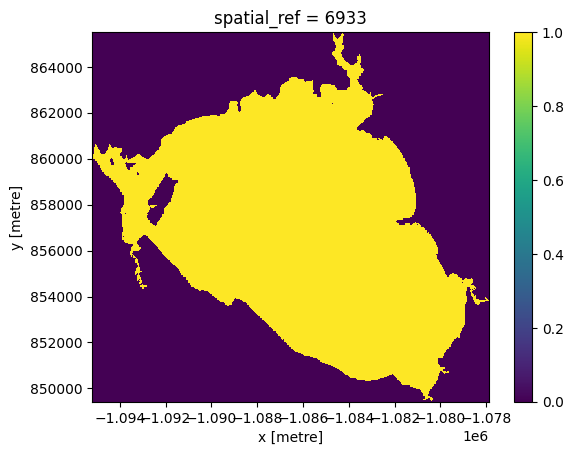

In [13]:
extent_da.plot()

In [14]:
_log.info(
    f"Processing per waterbody statistics for {ds.time.size} years for waterbody {waterbody_uid} ..."
)
df_drop_columns = ["spatial_ref"]

2026-03-13 21:47:11,272 __main__ [INFO]: Processing per waterbody statistics for 25 years for waterbody e9pyrcs51q ...


In [15]:
_log.info(
    "Processing water area consistently indicating algae ..."
)
water_mask_count = (~ds["water_mask"].isnull()).sum(dim=("x", "y"))
fai_count = (~ds["fai"].isnull()).sum(dim=("x", "y"))
fai_cover = (
    fai_count / water_mask_count.where(water_mask_count > 0)
) * 100
fai_cover_df = fai_cover.to_dataframe(name="fai_cover").drop(
    columns=df_drop_columns
)
fai_cover_df

2026-03-13 21:47:32,272 __main__ [INFO]: Processing water area consistently indicating algae ...


,fai_cover
time,
2000-07-01 23:59:59.999999,0.496901
2001-07-02 11:59:59.999999,0.377276
2002-07-02 11:59:59.999999,0.468316
2003-07-02 11:59:59.999999,0.401234
2004-07-01 23:59:59.999999,0.556467
2005-07-02 11:59:59.999999,0.450054
2006-07-02 11:59:59.999999,0.507493
2007-07-02 11:59:59.999999,0.513380
2008-07-01 23:59:59.999999,0.568466


In [16]:
_log.info(
    "Processing water area consistently indicating vegetation ..."
)
ndvi_count = (~ds["ndvi"].isnull()).sum(dim=("x", "y"))
ndvi_cover = (
    ndvi_count / water_mask_count.where(water_mask_count > 0)
) * 100
ndvi_cover_df = ndvi_cover.to_dataframe(name="ndvi_cover").drop(
    columns=df_drop_columns
)
ndvi_cover_df

2026-03-13 21:47:46,273 __main__ [INFO]: Processing water area consistently indicating vegetation ...


,ndvi_cover
time,
2000-07-01 23:59:59.999999,5.834590
2001-07-02 11:59:59.999999,5.606576
2002-07-02 11:59:59.999999,6.753978
2003-07-02 11:59:59.999999,4.053698
2004-07-01 23:59:59.999999,8.377001
2005-07-02 11:59:59.999999,4.717358
2006-07-02 11:59:59.999999,5.826937
2007-07-02 11:59:59.999999,5.260481
2008-07-01 23:59:59.999999,4.766147


In [17]:
annual_quantile_measurements = [
    "hue",
    "owt",
    "chla",
    "tsi",
    "tsm",
    "st_max",
    "st_median",
    "st_min",
]
# Sanity check
assert set(annual_quantile_measurements).issubset(
    set(measurements)
)
assert set(annual_quantile_measurements).issubset(
    set(list(ds.data_vars))
)

In [18]:
quantiles_df_to_merge = []
for measurement in annual_quantile_measurements:
    _log.info(
        f"Processing per waterbody quantiles for the {measurement} variable"
    )
    quantiles_df = (
        ds[measurement]
        .quantile(quantiles, dim=("x", "y"))
        .to_dataframe()
        .unstack("quantile")
    )
    quantiles_df.columns = [
        f"{measurement}_q{q}".replace(".", "_")
        for _, q in quantiles_df.columns
    ]
    quantiles_df_to_merge.append(quantiles_df)

2026-03-13 21:48:19,396 __main__ [INFO]: Processing per waterbody quantiles for the hue variable
2026-03-13 21:48:33,921 __main__ [INFO]: Processing per waterbody quantiles for the owt variable
2026-03-13 21:48:37,636 __main__ [INFO]: Processing per waterbody quantiles for the chla variable
2026-03-13 21:48:42,521 __main__ [INFO]: Processing per waterbody quantiles for the tsi variable
2026-03-13 21:48:47,527 __main__ [INFO]: Processing per waterbody quantiles for the tsm variable
2026-03-13 21:48:52,503 __main__ [INFO]: Processing per waterbody quantiles for the st_max variable
2026-03-13 21:48:57,381 __main__ [INFO]: Processing per waterbody quantiles for the st_median variable
2026-03-13 21:49:02,091 __main__ [INFO]: Processing per waterbody quantiles for the st_min variable


In [19]:
per_waterbody_summaries = pd.concat(
    [*quantiles_df_to_merge, fai_cover_df, ndvi_cover_df], axis=1
)
per_waterbody_summaries = per_waterbody_summaries.reset_index()

per_waterbody_summaries["uid"] = waterbody_uid

per_waterbody_summaries["obs_id"] = (
    per_waterbody_summaries["time"].dt.strftime("%Y/%m/%d")
    + "_"
    + per_waterbody_summaries["uid"]
)
per_waterbody_summaries = per_waterbody_summaries.rename(
    columns={"time": "date"}
)

cols = per_waterbody_summaries.columns.tolist()
cols.insert(0, cols.pop(cols.index("uid")))
cols.insert(0, cols.pop(cols.index("obs_id")))
per_waterbody_summaries = per_waterbody_summaries[cols]

per_waterbody_summaries

,obs_id,uid,date,hue_q0_1,hue_q0_2,hue_q0_3,hue_q0_4,hue_q0_5,hue_q0_6,hue_q0_7,...,st_min_q0_2,st_min_q0_3,st_min_q0_4,st_min_q0_5,st_min_q0_6,st_min_q0_7,st_min_q0_8,st_min_q0_9,fai_cover,ndvi_cover
0,2000/07/01_e9pyrcs51q,e9pyrcs51q,2000-07-01 23:59:59.999999,51.833571,62.360356,69.065529,74.127634,78.255943,81.829710,85.489527,...,29.606573,29.895391,30.071417,30.251167,30.418346,30.577473,30.751644,31.052956,0.496901,5.834590
1,2001/07/02_e9pyrcs51q,e9pyrcs51q,2001-07-02 11:59:59.999999,51.237616,62.668249,70.871441,75.109227,77.919678,80.312401,82.582664,...,25.239010,25.897707,26.379387,26.747622,27.071413,27.353394,27.671612,28.198067,0.377276,5.606576
2,2002/07/02_e9pyrcs51q,e9pyrcs51q,2002-07-02 11:59:59.999999,50.507807,61.440707,69.111393,73.917496,77.063850,79.301401,81.214661,...,26.528099,26.796030,27.050301,27.315453,27.615324,27.942543,28.246178,28.580923,0.468316,6.753978
3,2003/07/02_e9pyrcs51q,e9pyrcs51q,2003-07-02 11:59:59.999999,52.229044,61.848031,68.360712,71.489726,73.464684,75.008675,76.458992,...,27.001678,27.121307,27.241695,27.361021,27.497854,27.648283,27.883871,28.311776,0.401234,4.053698
4,2004/07/01_e9pyrcs51q,e9pyrcs51q,2004-07-01 23:59:59.999999,52.363608,62.636166,68.797789,72.876364,75.966553,78.758279,81.697624,...,26.711151,27.127697,27.451603,27.735260,28.096496,29.229129,30.671726,31.174513,0.556467,8.377001
5,2005/07/02_e9pyrcs51q,e9pyrcs51q,2005-07-02 11:59:59.999999,58.525152,64.694400,71.724014,76.191339,79.084084,81.228729,83.105000,...,20.697792,21.756302,23.607599,26.556665,27.536615,29.356720,29.855743,30.318428,0.450054,4.717358
6,2006/07/02_e9pyrcs51q,e9pyrcs51q,2006-07-02 11:59:59.999999,55.027792,64.596146,70.987652,74.857045,77.605164,79.826462,81.847916,...,20.724152,21.786367,22.735992,24.615218,26.489592,26.926830,27.249146,27.902129,0.507493,5.826937
7,2007/07/02_e9pyrcs51q,e9pyrcs51q,2007-07-02 11:59:59.999999,55.435841,63.686958,68.869072,71.901245,74.197792,75.816666,77.175423,...,25.560434,25.857330,26.119616,26.329583,26.532734,26.754066,27.112080,28.017605,0.513380,5.260481
8,2008/07/01_e9pyrcs51q,e9pyrcs51q,2008-07-01 23:59:59.999999,55.228100,65.839462,73.153831,77.301041,80.194756,82.743584,85.291122,...,26.560155,27.068899,27.444876,27.737680,28.159016,28.716606,30.935822,31.903107,0.568466,4.766147
9,2009/07/02_e9pyrcs51q,e9pyrcs51q,2009-07-02 11:59:59.999999,51.979122,65.486942,74.153404,78.949371,82.004646,84.487572,87.005127,...,24.118256,24.684835,25.226816,25.873655,26.762302,27.560186,28.050995,28.732228,0.578289,7.896130


In [20]:
add_water_quality_observations_to_db(
    water_quality_measures=per_waterbody_summaries,
    engine=engine,
    update_rows=overwrite,
)
_log.info(
    f"Finished processing water quality summaries the waterbody {waterbody_uid}"
)

2026-03-13 21:49:24,307 water_quality.summaries.summary [INFO]: Found 0 out of 25 waterbody observations already in the waterbodies_water_quality table
2026-03-13 21:49:24,311 water_quality.summaries.summary [INFO]: No water quality observations to update in the waterbodies_water_quality table
2026-03-13 21:49:24,311 water_quality.summaries.summary [INFO]: Inserting 25 water quality observations in the waterbodies_water_quality table
2026-03-13 21:49:24,324 __main__ [INFO]: Finished processing water quality summaries the waterbody e9pyrcs51q
